# Ucitavanje potrebnih biblioteka

In [1]:
USE_WIDGETS = True

def importEssentialLibs(USE_WIDGETS):
    import numpy as np
    if USE_WIDGETS:
        %matplotlib widget
    else:
        %matplotlib inline
    import matplotlib as mpl
    mpl.rc('text', usetex = True)
    mpl.rc('font', family = 'serif', size = 18)
    import matplotlib.pyplot as plt
    
    return np, mpl, plt

np, mpl, plt = importEssentialLibs(USE_WIDGETS)
from IPython.display import Markdown, display
# mpl.rc('text', usetex = True)
import scipy.fft as fft
import IPython
from IPython.display import Markdown
from scipy.io import wavfile
from scipy.signal import chirp, spectrogram
import scipy.signal as signal
import pickle 
import scipy.io as sio
from scipy.signal import butter, lfilter, freqz
from scipy.signal import firwin, convolve
from fxpmath import Fxp
from signal_utils import *

In [2]:
N = 1024
D = 2
n_frac = 7

# Dizajn FIR filtra

$F_{max} = 0.425$

$F_{\text{pass}} = 0.1300, \quad F_{\text{stop}} = 0.2300$

$N_{FIR} = 21$

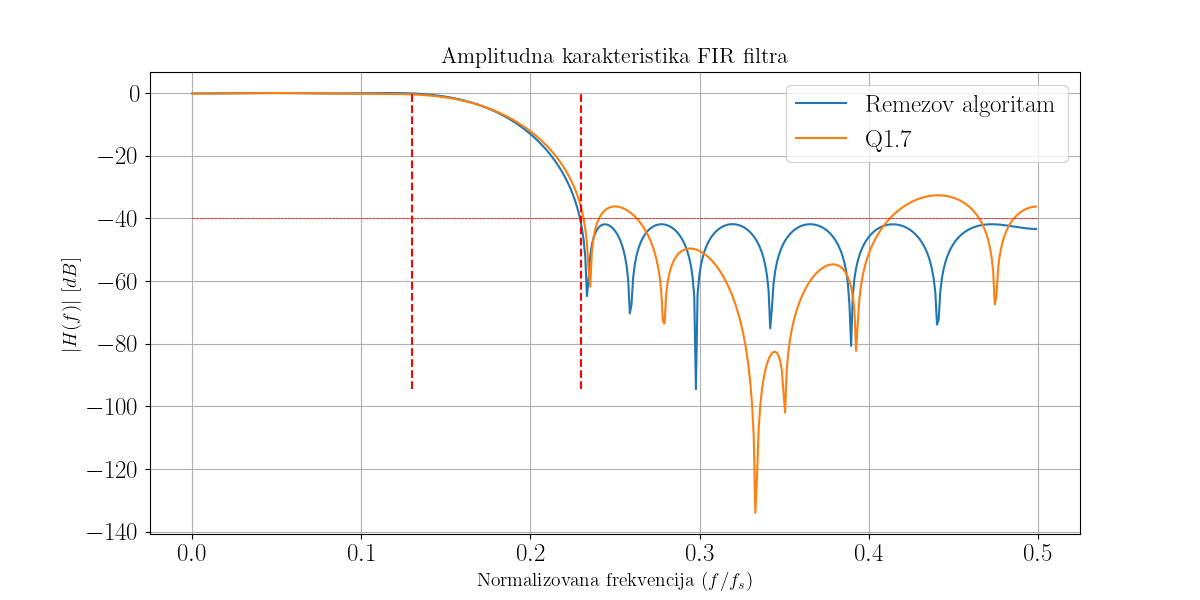

Filtar dobijen Remezovim algoritmom:
[-0.00862784 -0.0093991   0.00759768  0.02431604  0.01719255 -0.02873713
 -0.06446049 -0.02412427  0.11786376  0.28422295  0.36022782  0.28422295
  0.11786376 -0.02412427 -0.06446049 -0.02873713  0.01719255  0.02431604
  0.00759768 -0.0093991  -0.00862784]

Filtar u reprezentaciji Q1.7:
[-1, -1, 0, 3, 2, -3, -8, -3, 15, 36, 46, 36, 15, -3, -8, -3, 2, 3, 0, -1, -1]


In [3]:
AdB = 40

deltaPass = 10**(-AdB/20)
deltaStop = deltaPass

perc = 0.15
Fmax = 0.5 * (1 - perc)
display(Markdown((rf"$F_{{max}} = {Fmax}$")))
Fstop = 0.23
Fpass = Fstop - 0.1

display(Markdown(rf"$F_{{\text{{pass}}}} = {Fpass:.4f}, \quad F_{{\text{{stop}}}} = {Fstop:.4f}$"))

firCoeff = remezlp(Fpass, Fstop, deltaPass, deltaStop, even_n=False, nPoints=N, Nmax=N)
firCoeff_q1n = float_to_q1n(firCoeff, n_frac)

display(Markdown(rf"$N_{{FIR}} = {len(firCoeff)}$"))

w, h = scipy.signal.freqz(firCoeff)
H = 20*np.log10(abs(h))
H -= np.max(H)

w_q1n, h_q1n = scipy.signal.freqz(firCoeff_q1n)
H_q1n = 20*np.log10(abs(h_q1n))
H_q1n -= np.max(H_q1n)

plt.figure(figsize=(12,6))
plt.plot(w/(2*np.pi), H, label="Remezov algoritam");
plt.plot(w_q1n/(2*np.pi), H_q1n, label=f"Q1.{n_frac}");
# plt.plot(w_hb/(2*np.pi), H_hb, label="HB korekcija");
plt.plot([0, 0.5], [-AdB, -AdB], 'r--', linewidth=0.5)
plt.plot([Fpass,Fpass], [np.min(H), 0], 'r--');
plt.plot([Fstop,Fstop], [np.min(H), 0], 'r--');
plt.legend()
plt.title(r'Amplitudna karakteristika FIR filtra', fontsize=16)
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.grid(True)
plt.show();

np.set_printoptions(suppress=True)
print("Filtar dobijen Remezovim algoritmom:")
print(firCoeff)
print(f"\nFiltar u reprezentaciji Q1.{n_frac}:")
print(firCoeff_q1n)

# Testni signal

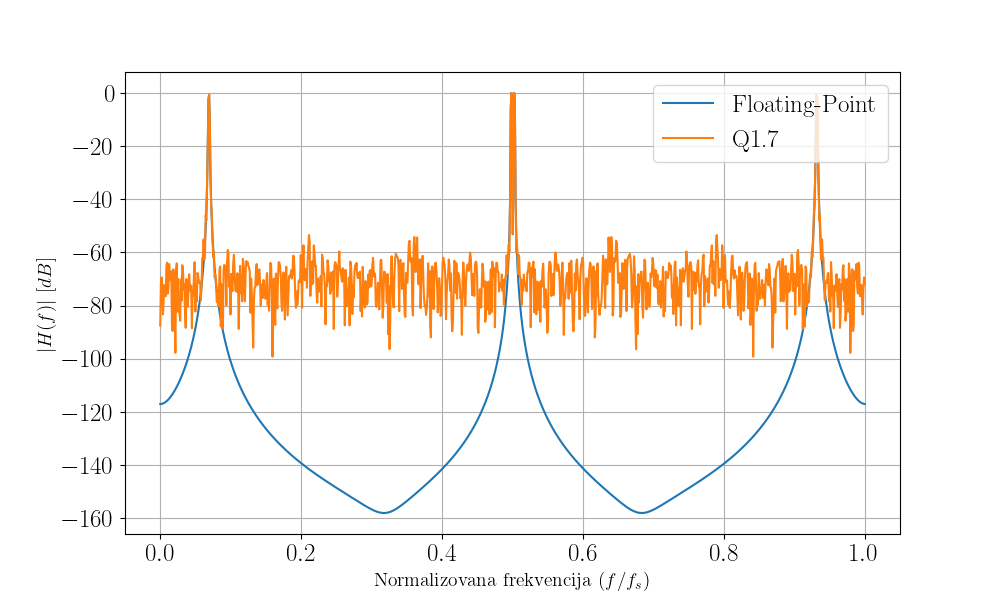

In [4]:
n = np.arange(N)
F1 = 0.002
F2 = 0.431

xin = 1.0*np.sin(2*np.pi*F1*n) + 1.0*np.sin(2*np.pi*F2*n)
xin /= np.max(xin)

xin_q1n = float_to_q1n(xin, n_frac)

xin_fftdB = fftdB(xin, win=True)
xin_fftdB -= np.max(xin_fftdB)
xin_q1n_fftdB = fftdB(xin_q1n, win=True)
xin_q1n_fftdB -= np.max(xin_q1n_fftdB)
freqs = np.linspace(0, 1, N)

plt.figure(figsize=(10, 6))
plt.plot(freqs, xin_fftdB, label = "Floating-Point")
plt.plot(freqs, xin_q1n_fftdB, label = f"Q1.{n_frac}")
plt.grid()
plt.legend()
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.show();

# Priprema signala za obradu u VHDL-u

In [12]:
firCoeff_q1n_poly = makePolyphase(firCoeff_q1n, D)
print(firCoeff_q1n_poly)
xin_q1n_phase0 = xin_q1n[::D]
xin_q1n_phase1 = xin_q1n[1::D]

np.savetxt("../vhdl/fir_RAG/data/firCoeff_q1n_phase0.txt", firCoeff_q1n_poly[0], fmt="%d")
np.savetxt("../vhdl/fir_RAG/data/firCoeff_q1n_phase1.txt", firCoeff_q1n_poly[1], fmt="%d")
np.savetxt("../vhdl/fir_RAG/data/xin_q1n_phase0.txt", xin_q1n_phase0, fmt="%d")
np.savetxt("../vhdl/fir_RAG/data/xin_q1n_phase1.txt", xin_q1n_phase1, fmt="%d")
np.savetxt("../vhdl/fir_RAG/data/xin_q1n.txt", xin_q1n, fmt="%d")

[[-1  0  2 -8 15 46 15 -8  2  0 -1]
 [-1  3 -3 -3 36 36 -3 -3  3 -1  0]]


# Poredjenje VHDL i Python simulacije

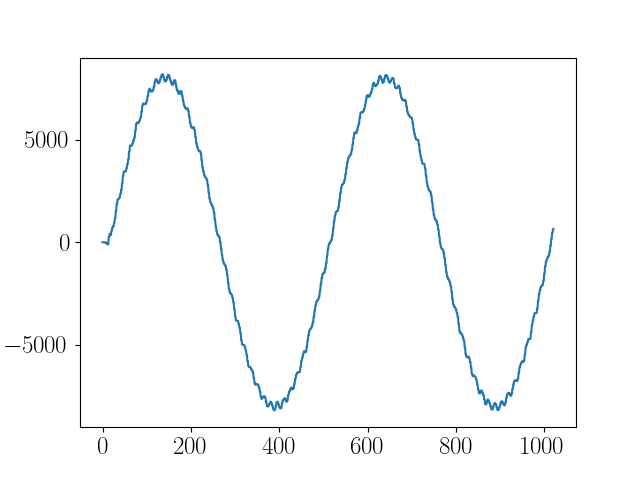

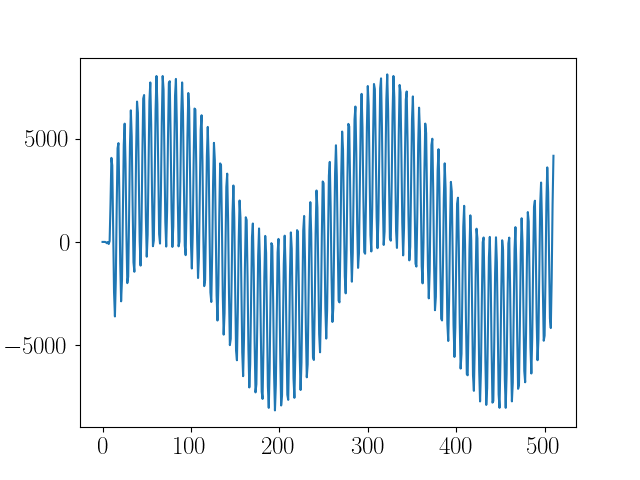

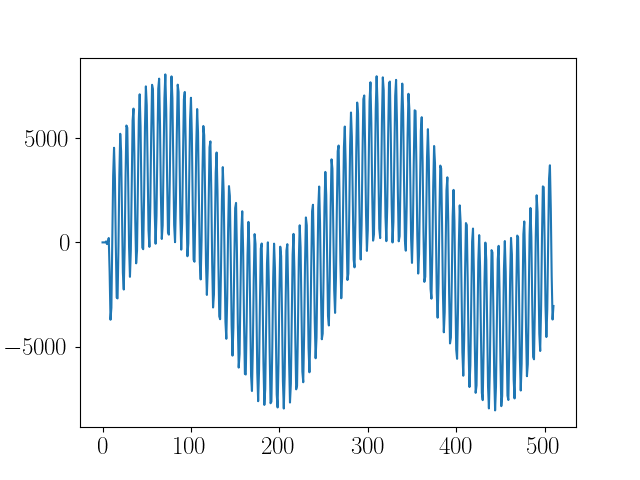

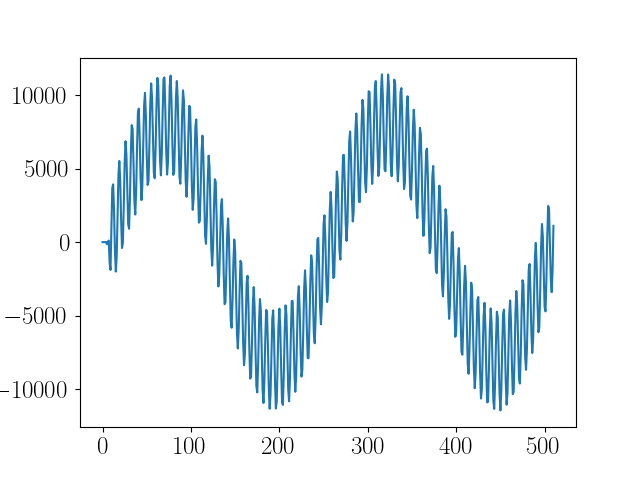

In [73]:
xout_dec_vhdl = np.loadtxt("../vhdl/poly_dec_RAG/data/xout_dec.txt", dtype=np.int32)
xout_dec0_vhdl = np.loadtxt("../vhdl/poly_dec_RAG/data/xout_dec_0.txt", dtype=np.int32)
xout_dec1_vhdl = np.loadtxt("../vhdl/poly_dec_RAG/data/xout_dec_1.txt", dtype=np.int32)

xout_dec0_vhdl = xout_dec0_vhdl[::2]
xout_dec1_vhdl = xout_dec1_vhdl[::2]

plt.figure()
plt.plot(xout_dec_vhdl)

plt.figure()
plt.plot(xout_dec0_vhdl)

plt.figure()
plt.plot(xout_dec1_vhdl)

plt.figure()
plt.plot(xout_dec0_vhdl + xout_dec1_vhdl)

/tmp/ipykernel_76226/47907492.py:1: UserWarning: loadtxt: input contained no data: "../vhdl/fir_RAG/data/xout_phase0.txt"
  xout_phase0_vhdl = np.loadtxt("../vhdl/fir_RAG/data/xout_phase0.txt", dtype=np.int32)
/tmp/ipykernel_76226/47907492.py:2: UserWarning: loadtxt: input contained no data: "../vhdl/fir_RAG/data/xout_phase1.txt"
  xout_phase1_vhdl = np.loadtxt("../vhdl/fir_RAG/data/xout_phase1.txt", dtype=np.int32)


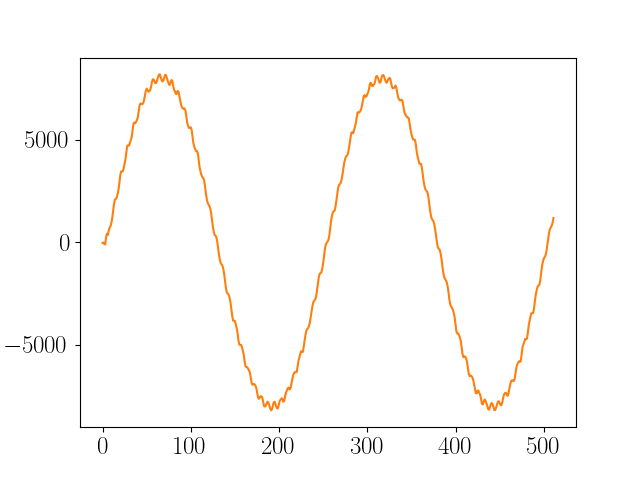

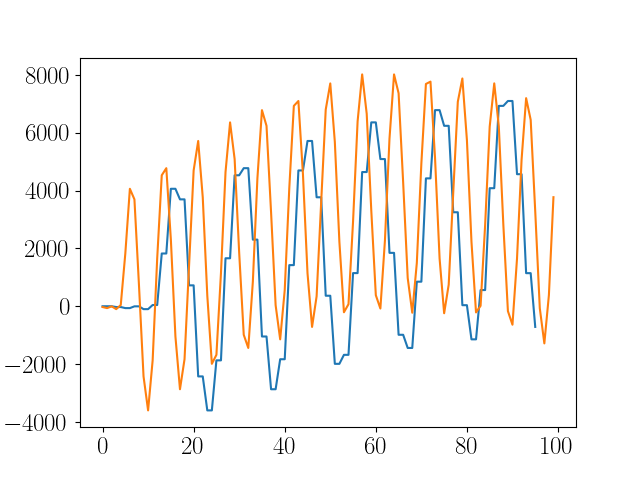

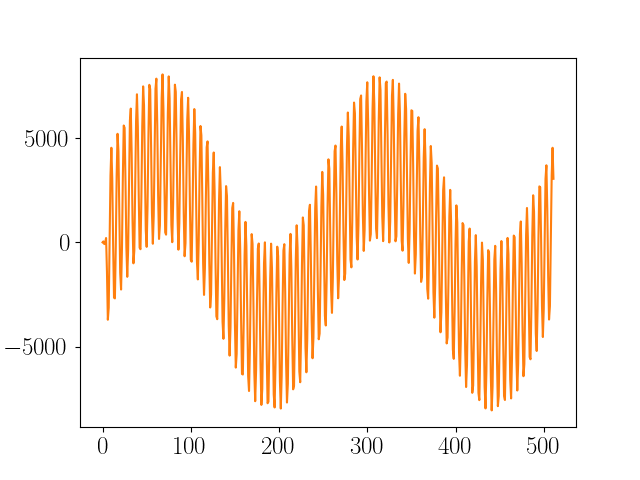

In [70]:
xout_phase0_vhdl = np.loadtxt("../vhdl/fir_RAG/data/xout_phase0.txt", dtype=np.int32)
xout_phase1_vhdl = np.loadtxt("../vhdl/fir_RAG/data/xout_phase1.txt", dtype=np.int32)

xout_phase0_py = fir_transposed_q1n(xin_q1n_phase1, firCoeff_q1n_poly[0], n_frac, saturate=False)
xout_phase1_py = fir_transposed_q1n(xin_q1n_phase0, firCoeff_q1n_poly[1], n_frac, saturate=False)

xout_vhdl = xout_phase0_vhdl + xout_phase1_vhdl
xout_py = xout_phase0_py + xout_phase1_py

plt.figure()
plt.plot(xout_vhdl[4:])
plt.plot(xout_py)

plt.figure()
# plt.plot(xout_phase0_vhdl[4:100])
plt.plot(xout_dec0_vhdl[4:100])
plt.plot(xout_phase0_py[:100])

plt.figure()
plt.plot(xout_phase1_vhdl[4:])
plt.plot(xout_phase1_py[:])

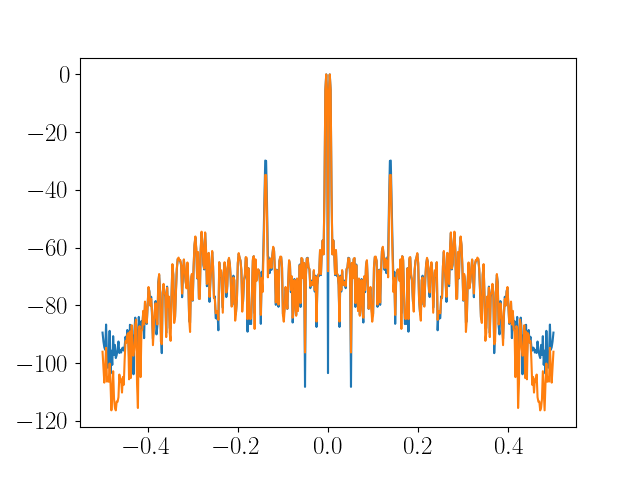

In [14]:
xout_vhdl_fftdB = fftdB(xout_vhdl, win=True)
xout_vhdl_fftdB -= np.max(xout_vhdl_fftdB)
xout_py_fftdB = fftdB(xout_py[:-1], win=True)
xout_py_fftdB -= np.max(xout_py_fftdB)

freqs_vhdl = np.linspace(-0.5, 0.5, len(xout_vhdl_fftdB))
freqs_py = np.linspace(-0.5, 0.5, len(xout_py_fftdB))

plt.figure()
plt.plot(freqs_vhdl, xout_vhdl_fftdB)
plt.plot(freqs_py, xout_py_fftdB)